<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/practical_9_lstm_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Techniques (DOAI250006)
## Institution: NIELIT ROPAR
## Practical 9: Time Series Forecasting with Multivariate LSTM

This notebook builds a robust Long Short-Term Memory (LSTM) network to predict stock prices. Unlike basic models, this implementation includes feature engineering (Moving Averages), Early Stopping to prevent overfitting, and independent feature/target scaling.

In [ ]:
!pip install yfinance --quiet

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 1. Data Fetching and Feature Engineering
We download Apple stock data and calculate two common technical indicators: the 20-day and 50-day Simple Moving Averages (SMA). These added features help the model understand short-term and medium-term trends.

/tmp/ipykernel_4855/1742377789.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2018-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


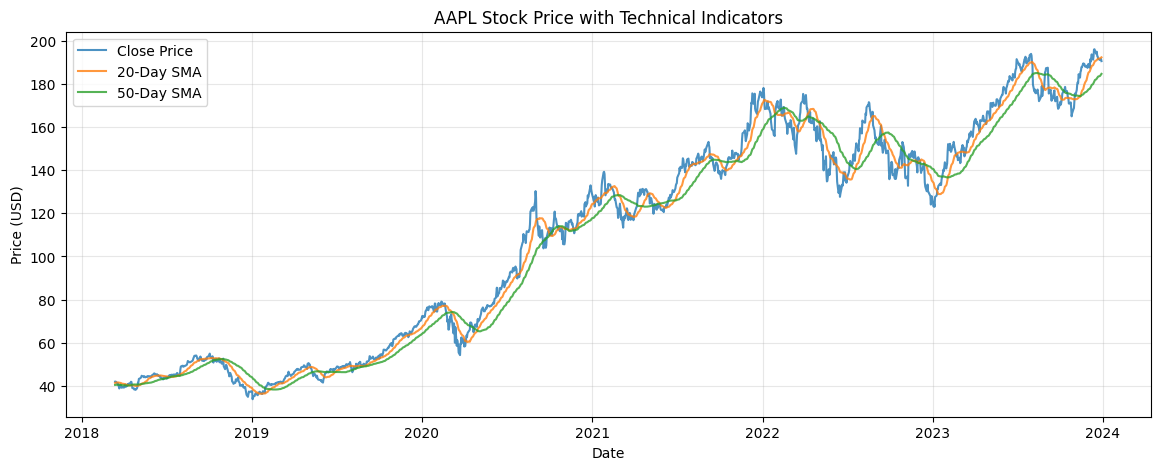

In [ ]:
# Fetch historical data
ticker = 'AAPL'
df = yf.download(ticker, start='2018-01-01', end='2024-01-01')

# Ensure we are working with a clean, single-level dataframe (handles yfinance multi-index)
if isinstance(df.columns, pd.MultiIndex):
    df = df.xs(ticker, level=1, axis=1) if ticker in df.columns.get_level_values(1) else df

df = df[['Close']].copy()

# Add Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Drop NaN values created by the rolling windows
df.dropna(inplace=True)

# Plot the engineered data
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.8)
plt.plot(df.index, df['SMA_20'], label='20-Day SMA', alpha=0.8)
plt.plot(df.index, df['SMA_50'], label='50-Day SMA', alpha=0.8)
plt.title(f'{ticker} Stock Price with Technical Indicators')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2. Preprocessing and Independent Scaling
Because we now have multiple input features but only want to predict a single output (Close price), using separate scalers for `X` and `y` prevents complex matrix reshaping during the final inverse transformation step.

In [ ]:
# Separate features (inputs) and target (output)
features = df[['Close', 'SMA_20', 'SMA_50']].values
target = df[['Close']].values

# Initialize separate scalers
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

# Scale the data
scaled_features = scaler_features.fit_transform(features)
scaled_target = scaler_target.fit_transform(target)

print(f"Shape of scaled features: {scaled_features.shape}")

Shape of scaled features: (1460, 3)


### 3. Sequence Creation and Chronological Splitting
We use a sliding window approach. The model will look at the past 60 days of Close, SMA_20, and SMA_50 to predict the Close price on day 61.

In [ ]:
def create_multivariate_sequences(features_data, target_data, time_step=60):
    X, y = [], []
    for i in range(len(features_data) - time_step):
        X.append(features_data[i:(i + time_step), :])
        y.append(target_data[i + time_step, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 60
X, y = create_multivariate_sequences(scaled_features, scaled_target, TIME_STEPS)

# Split into training (80%) and testing (20%) sets sequentially
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"X_train shape: {X_train.shape} -> (Samples, Time Steps, Features)")
print(f"y_train shape: {y_train.shape}")

X_train shape: (1120, 60, 3) -> (Samples, Time Steps, Features)
y_train shape: (1120,)


### 4. Building the Model with Early Stopping
We implement `EarlyStopping` to monitor the validation loss. If the validation loss stops improving for 5 consecutive epochs, training halts automatically and restores the best weights, ensuring we don't overfit to the training data.

In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Define the EarlyStopping callback
early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True,
                           verbose=1)

model.summary()

# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.1, # Use 10% of training data for validation
                    callbacks=[early_stop],
                    verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,545 (205.25 KB)

 Trainable params: 52,545 (205.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 291ms/step - loss: 0.0380 - val_loss: 0.0078
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0033 - val_loss: 0.0040
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0030 - val_loss: 0.0036
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0029 - val_loss: 0.0035
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0029 - val_loss: 0.0030
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0021 - val_loss: 0.0025
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0019 - val_loss: 0.0026
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 

### 5. Evaluation and Forecasting Visuals
Finally, we predict on the test set, calculate our error metrics in actual currency values, and map the predictions back against the dates for a clear visual representation.

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step

Root Mean Squared Error (RMSE): $6.06
Mean Absolute Error (MAE): $5.23


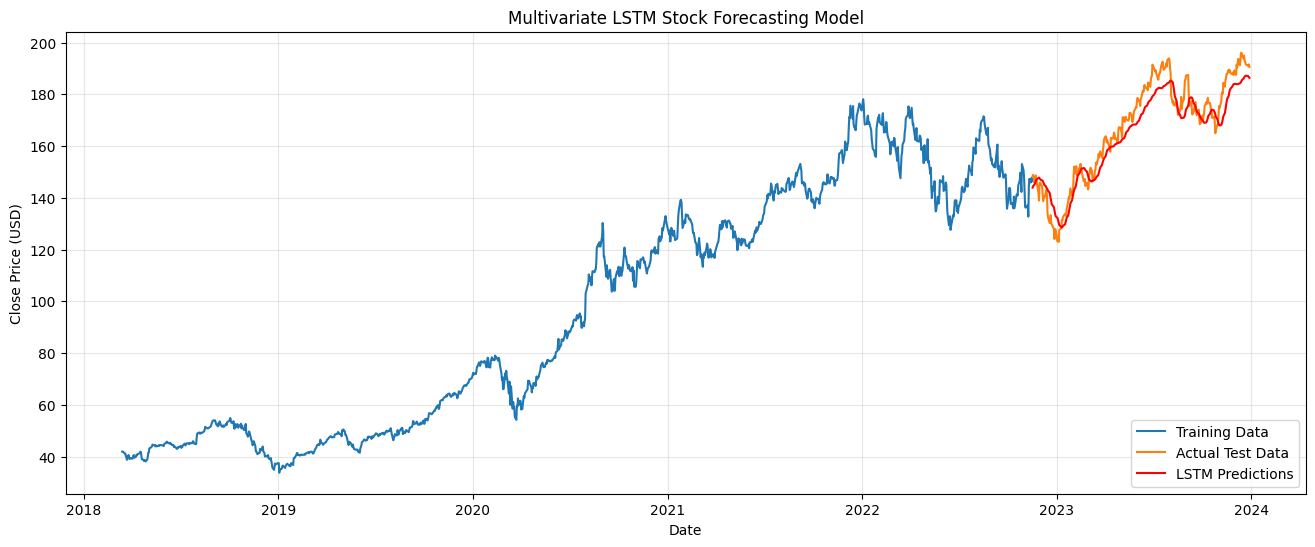

In [ ]:
# Make predictions
predictions_scaled = model.predict(X_test)

# Inverse transform to get actual stock prices
predictions = scaler_target.inverse_transform(predictions_scaled)
y_test_actual = scaler_target.inverse_transform(y_test.reshape(-1, 1))

# Calculate Error Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)
print(f"\nRoot Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")

# Prepare data for plotting
train_data_len = split_idx + TIME_STEPS
train = df.iloc[:train_data_len].copy()
valid = df.iloc[train_data_len:].copy()
valid['Predictions'] = predictions

# Plotting
plt.figure(figsize=(16, 6))
plt.title('Multivariate LSTM Stock Forecasting Model')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.plot(train.index, train['Close'], label='Training Data')
plt.plot(valid.index, valid['Close'], label='Actual Test Data')
plt.plot(valid.index, valid['Predictions'], label='LSTM Predictions', color='red')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()